In [3]:

# # once environment kur 
# conda create -n adult_ml python=3.12

# # environment i aktif et 
# conda activate adult_ml

# #sonra gerekli kutuphaneleri kur 
# pip install pandas numpy scikit-learn fastapi uvicorn

# #bunlarda diger kutuphaneler 
# pip install matplotlib seaborn jupyter

# #ekstra
# pip install ipykernel
# python -m ipykernel install --user --name adult_ml


# pip install missingno 

In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
import missingno as msn

In [5]:
df = pd.read_csv('adult.csv')

In [6]:
df.head(5)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [7]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [8]:
df.sample(15)
## first observe: 
# in native.country, workclass, occupation fields there are question mark (?) ->
# we need unique function. 

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
3438,31,Private,213643,HS-grad,9,Married-civ-spouse,Sales,Husband,White,Male,3908,0,40,United-States,<=50K
27349,34,Private,179378,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,Black,Female,0,0,40,United-States,<=50K
16405,33,Private,159303,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K
7879,41,Self-emp-not-inc,190290,HS-grad,9,Divorced,Craft-repair,Not-in-family,White,Male,0,0,40,United-States,<=50K
31422,28,Private,110981,Some-college,10,Never-married,Other-service,Not-in-family,White,Male,0,0,40,United-States,<=50K
29899,36,Private,138441,Assoc-acdm,12,Married-civ-spouse,Tech-support,Husband,White,Male,0,0,55,United-States,<=50K
23397,28,Private,239130,Some-college,10,Never-married,Exec-managerial,Not-in-family,White,Male,0,0,50,United-States,<=50K
29019,24,Private,403671,HS-grad,9,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,60,United-States,<=50K
27371,40,State-gov,377018,Bachelors,13,Married-civ-spouse,Prof-specialty,Husband,White,Male,0,0,60,United-States,>50K
12239,58,State-gov,400285,HS-grad,9,Married-civ-spouse,Adm-clerical,Husband,Black,Male,0,0,40,United-States,>50K


In [9]:
df.sample(1)

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
28737,21,Private,126613,Some-college,10,Never-married,Other-service,Own-child,White,Female,0,0,40,United-States,<=50K


In [10]:
df.info()
# Looks like the data types are proper. 
# we will need ,dummy operation later for categorical features

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  str  
 6   occupation      32561 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 3.7 MB


In [11]:
df.describe().T
# Probably there are lots of outliers in capital.gain and capital.loss fields
# std > mean 
# in these fields values are too high. 

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education.num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital.gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital.loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours.per.week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [12]:
df.shape

(32561, 15)

In [13]:
df.isnull().sum().sum()
# There is no null value 

np.int64(0)

<Axes: >

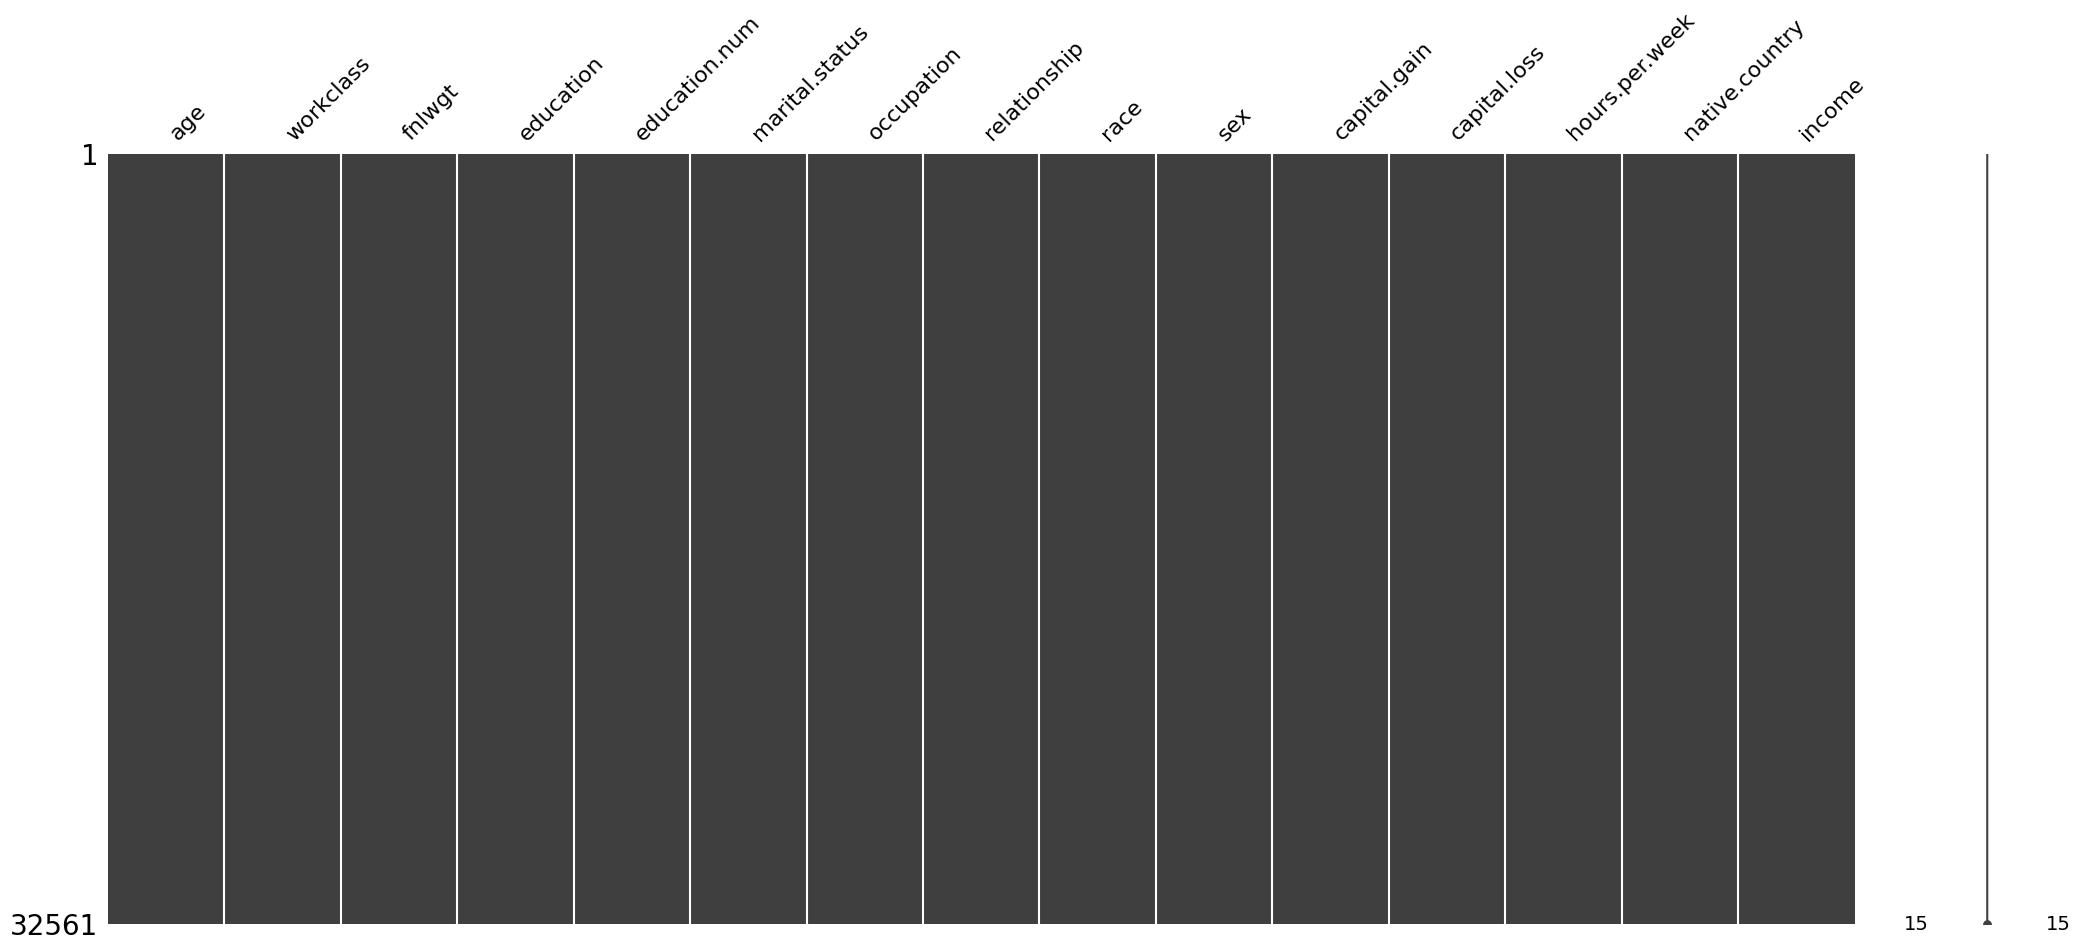

In [14]:
msn.matrix(df)

In [15]:
df.columns
# There are . notations in the names of fields, not useful, lets fix it. 

Index(['age', 'workclass', 'fnlwgt', 'education', 'education.num',
       'marital.status', 'occupation', 'relationship', 'race', 'sex',
       'capital.gain', 'capital.loss', 'hours.per.week', 'native.country',
       'income'],
      dtype='str')

In [16]:
df.columns = ['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income']
df.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education_num',
       'marital_status', 'occupation', 'relationship', 'race', 'sex',
       'capital_gain', 'capital_loss', 'hours_per_week', 'native_country',
       'income'],
      dtype='str')

In [17]:
df.sample()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
1505,41,Private,332703,HS-grad,9,Divorced,Adm-clerical,Not-in-family,Other,Female,0,625,40,United-States,<=50K


In [18]:
df['education']

0             HS-grad
1             HS-grad
2        Some-college
3             7th-8th
4        Some-college
             ...     
32556    Some-college
32557      Assoc-acdm
32558         HS-grad
32559         HS-grad
32560         HS-grad
Name: education, Length: 32561, dtype: str

In [19]:
df['workclass'].value_counts()
# 1836 ?

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [20]:
df.replace('?','Uknown',inplace=True)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,90,Uknown,77053,HS-grad,9,Widowed,Uknown,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,Uknown,186061,Some-college,10,Widowed,Uknown,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [21]:
df.sample()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
5921,49,Private,268022,Bachelors,13,Married-civ-spouse,Sales,Husband,White,Male,0,0,50,United-States,>50K


In [22]:
df.native_country.value_counts()
# All the ? in the data set is converted to Uknown

native_country
United-States                 29170
Mexico                          643
Uknown                          583
Philippines                     198
Germany                         137
Canada                          121
Puerto-Rico                     114
El-Salvador                     106
India                           100
Cuba                             95
England                          90
Jamaica                          81
South                            80
China                            75
Italy                            73
Dominican-Republic               70
Vietnam                          67
Guatemala                        64
Japan                            62
Poland                           60
Columbia                         59
Taiwan                           51
Haiti                            44
Iran                             43
Portugal                         37
Nicaragua                        34
Peru                             31
Greece       

In [23]:
df.occupation.value_counts()
# All the ? in the data set is converted to Uknown

occupation
Prof-specialty       4140
Craft-repair         4099
Exec-managerial      4066
Adm-clerical         3770
Sales                3650
Other-service        3295
Machine-op-inspct    2002
Uknown               1843
Transport-moving     1597
Handlers-cleaners    1370
Farming-fishing       994
Tech-support          928
Protective-serv       649
Priv-house-serv       149
Armed-Forces            9
Name: count, dtype: int64

In [24]:
df.workclass.value_counts()
# All the ? in the data set is converted to Uknown

workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
Uknown               1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64

In [25]:
for col in df.select_dtypes('object'):
    print(col)
    print('_________________________________')
    print(df[col].value_counts())
    print('_________________________________')


workclass
_________________________________
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
Uknown               1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
_________________________________
education
_________________________________
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate         413
5th-6th           333
1st-4th           168
Preschool          51
Name: count, dtype: int64
_________________________________
marital_status
_________________________________
marital_status
Married-civ-spouse       14976
Never-married            10683
Divorced                  4443
Separated                 102

C:\Users\missena\AppData\Local\Temp\ipykernel_6284\383566021.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes('object'):


In [26]:
# There are more man than woman, at least double.
# There are mostly white people. 
# Mostly husband.
# Mostly working Private 


In [27]:
df.duplicated().sum()
# There are duplicate values. 

np.int64(24)

In [28]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns))
## we need to control if this data is real or not. Because it might be real, 
# there might be really 2 or 3 people who live in the same country, take the same type education, has the same gender, has the same race. 
# so we might keep this data, but if this data is not real, if its entered by mistake, 
# then we could delete this data. 

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
19622,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
20507,19,Private,97261,HS-grad,9,Never-married,Farming-fishing,Not-in-family,White,Male,0,0,40,United-States,<=50K
10307,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
22783,19,Private,138153,Some-college,10,Never-married,Adm-clerical,Own-child,White,Female,0,0,10,United-States,<=50K
17456,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
22934,19,Private,146679,Some-college,10,Never-married,Exec-managerial,Own-child,Black,Male,0,0,30,United-States,<=50K
7615,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
32065,19,Private,251579,Some-college,10,Never-married,Other-service,Own-child,White,Male,0,0,14,United-States,<=50K
9269,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K
14346,20,Private,107658,Some-college,10,Never-married,Tech-support,Not-in-family,White,Female,0,0,10,United-States,<=50K


In [29]:
def duplicate_values(df):
    print("Duplicate check...")
    num_duplicates = df.duplicated(subset=None, keep='first').sum()
    if num_duplicates > 0:
        print("There are", num_duplicates, "duplicated observations in the dataset.")
        df.drop_duplicates(keep='first', inplace=True)
        print(num_duplicates, "duplicates were dropped!")
        print("No more duplicate rows!")
    else:
        print("There are no duplicated observations in the dataset.")

In [30]:
duplicate_values(df)

Duplicate check...
There are 24 duplicated observations in the dataset.
24 duplicates were dropped!
No more duplicate rows!


In [31]:
df[df.duplicated(keep=False)].sum()

age               0
workclass          
fnlwgt            0
education          
education_num     0
marital_status     
occupation         
relationship       
race               
sex                
capital_gain      0
capital_loss      0
hours_per_week    0
native_country     
income             
dtype: object

In [32]:
for col in df.select_dtypes('object'):
    print('_________________________________')
    print(col, end=' -> ')
    print(df[col].nunique())
    print(df[col].unique())
    print('_________________________________')


_________________________________
workclass -> 9
<StringArray>
[          'Uknown',          'Private',        'State-gov',
      'Federal-gov', 'Self-emp-not-inc',     'Self-emp-inc',
        'Local-gov',      'Without-pay',     'Never-worked']
Length: 9, dtype: str
_________________________________
_________________________________
education -> 16
<StringArray>
[     'HS-grad', 'Some-college',      '7th-8th',         '10th',
    'Doctorate',  'Prof-school',    'Bachelors',      'Masters',
         '11th',   'Assoc-acdm',    'Assoc-voc',      '1st-4th',
      '5th-6th',         '12th',          '9th',    'Preschool']
Length: 16, dtype: str
_________________________________
_________________________________
marital_status -> 7
<StringArray>
[              'Widowed',              'Divorced',             'Separated',
         'Never-married',    'Married-civ-spouse', 'Married-spouse-absent',
     'Married-AF-spouse']
Length: 7, dtype: str
_________________________________
_______________

C:\Users\missena\AppData\Local\Temp\ipykernel_6284\963949421.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes('object'):


In [33]:
for col in df.select_dtypes('object'):
    print(f"{col:<20}:", df[col].nunique())

workclass           : 9
education           : 16
marital_status      : 7
occupation          : 15
relationship        : 6
race                : 5
sex                 : 2
native_country      : 42
income              : 2


C:\Users\missena\AppData\Local\Temp\ipykernel_6284\466863665.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes('object'):


In [34]:
df.select_dtypes(include='number').corr()
# In this data set , multicollinearity problem is not observed. 

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.076447,0.036224,0.077676,0.057745,0.068515
fnlwgt,-0.076447,1.000000,-0.043388,0.000429,-0.010260,-0.018898
education_num,0.036224,-0.043388,1.000000,0.122664,0.079892,0.148422
capital_gain,0.077676,0.000429,0.122664,1.000000,-0.031639,0.078408
capital_loss,0.057745,-0.010260,0.079892,-0.031639,1.000000,0.054229
hours_per_week,0.068515,-0.018898,0.148422,0.078408,0.054229,1.000000


# Data Visualization

In [35]:
df.sample()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
14380,36,Private,177285,Assoc-voc,11,Never-married,Prof-specialty,Unmarried,Black,Female,0,0,38,United-States,<=50K


C:\Users\missena\AppData\Local\Temp\ipykernel_6284\1801204856.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='income', palette='viridis')


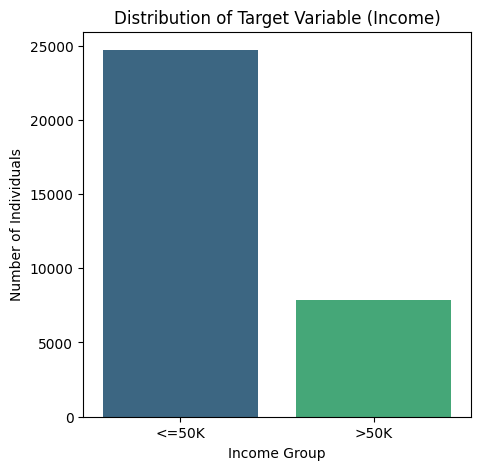

In [36]:
plt.figure(figsize=(5, 5))
sns.countplot(data=df, x='income', palette='viridis')

plt.title('Distribution of Target Variable (Income)')
plt.xlabel('Income Group')
plt.ylabel('Number of Individuals')
plt.show()
# We clearly see that mostly people earn less than 50K

In [37]:
df.sample()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
9731,41,Self-emp-not-inc,226505,HS-grad,9,Divorced,Other-service,Unmarried,White,Female,0,0,40,United-States,<=50K


In [38]:
df.groupby('native_country')['income'].value_counts()

native_country  income
Cambodia        <=50K       12
                >50K         7
Canada          <=50K       82
                >50K        39
China           <=50K       55
                          ... 
United-States   >50K      7169
Vietnam         <=50K       62
                >50K         5
Yugoslavia      <=50K       10
                >50K         6
Name: count, Length: 82, dtype: int64

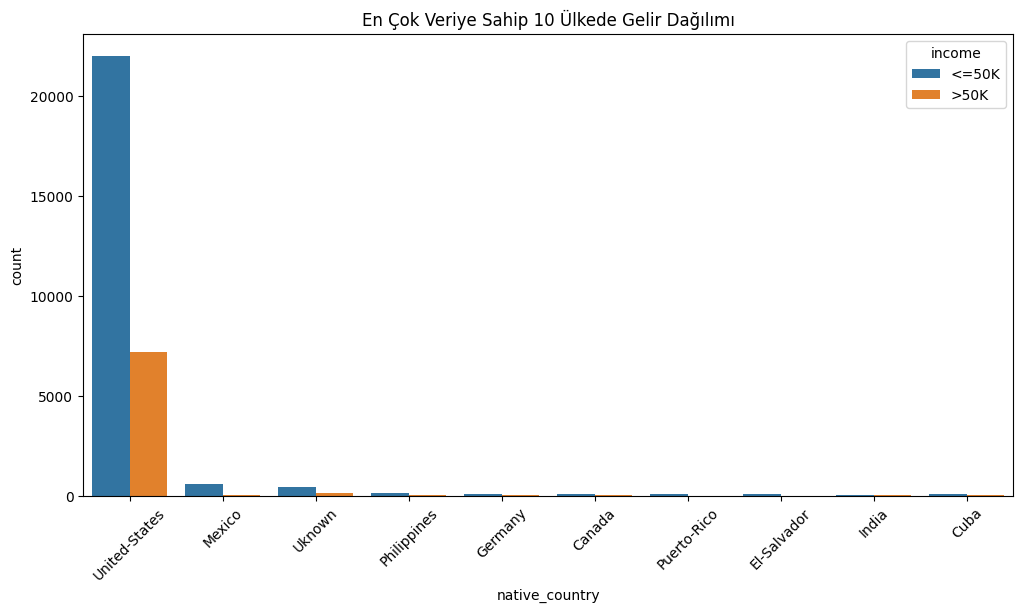

In [39]:
# En fazla verisi olan ilk 10 ülkeyi seçiyoruz
top_10_countries = df['native_country'].value_counts().nlargest(10).index
# Sadece bu 10 ülkeye ait verileri filtrele
df_top = df[df['native_country'].isin(top_10_countries)]

# Grafiği oluştur
plt.figure(figsize=(12, 6))
sns.countplot(data=df_top, x='native_country', hue='income', order=top_10_countries)

plt.title('En Çok Veriye Sahip 10 Ülkede Gelir Dağılımı')
plt.xticks(rotation=45)
plt.show()

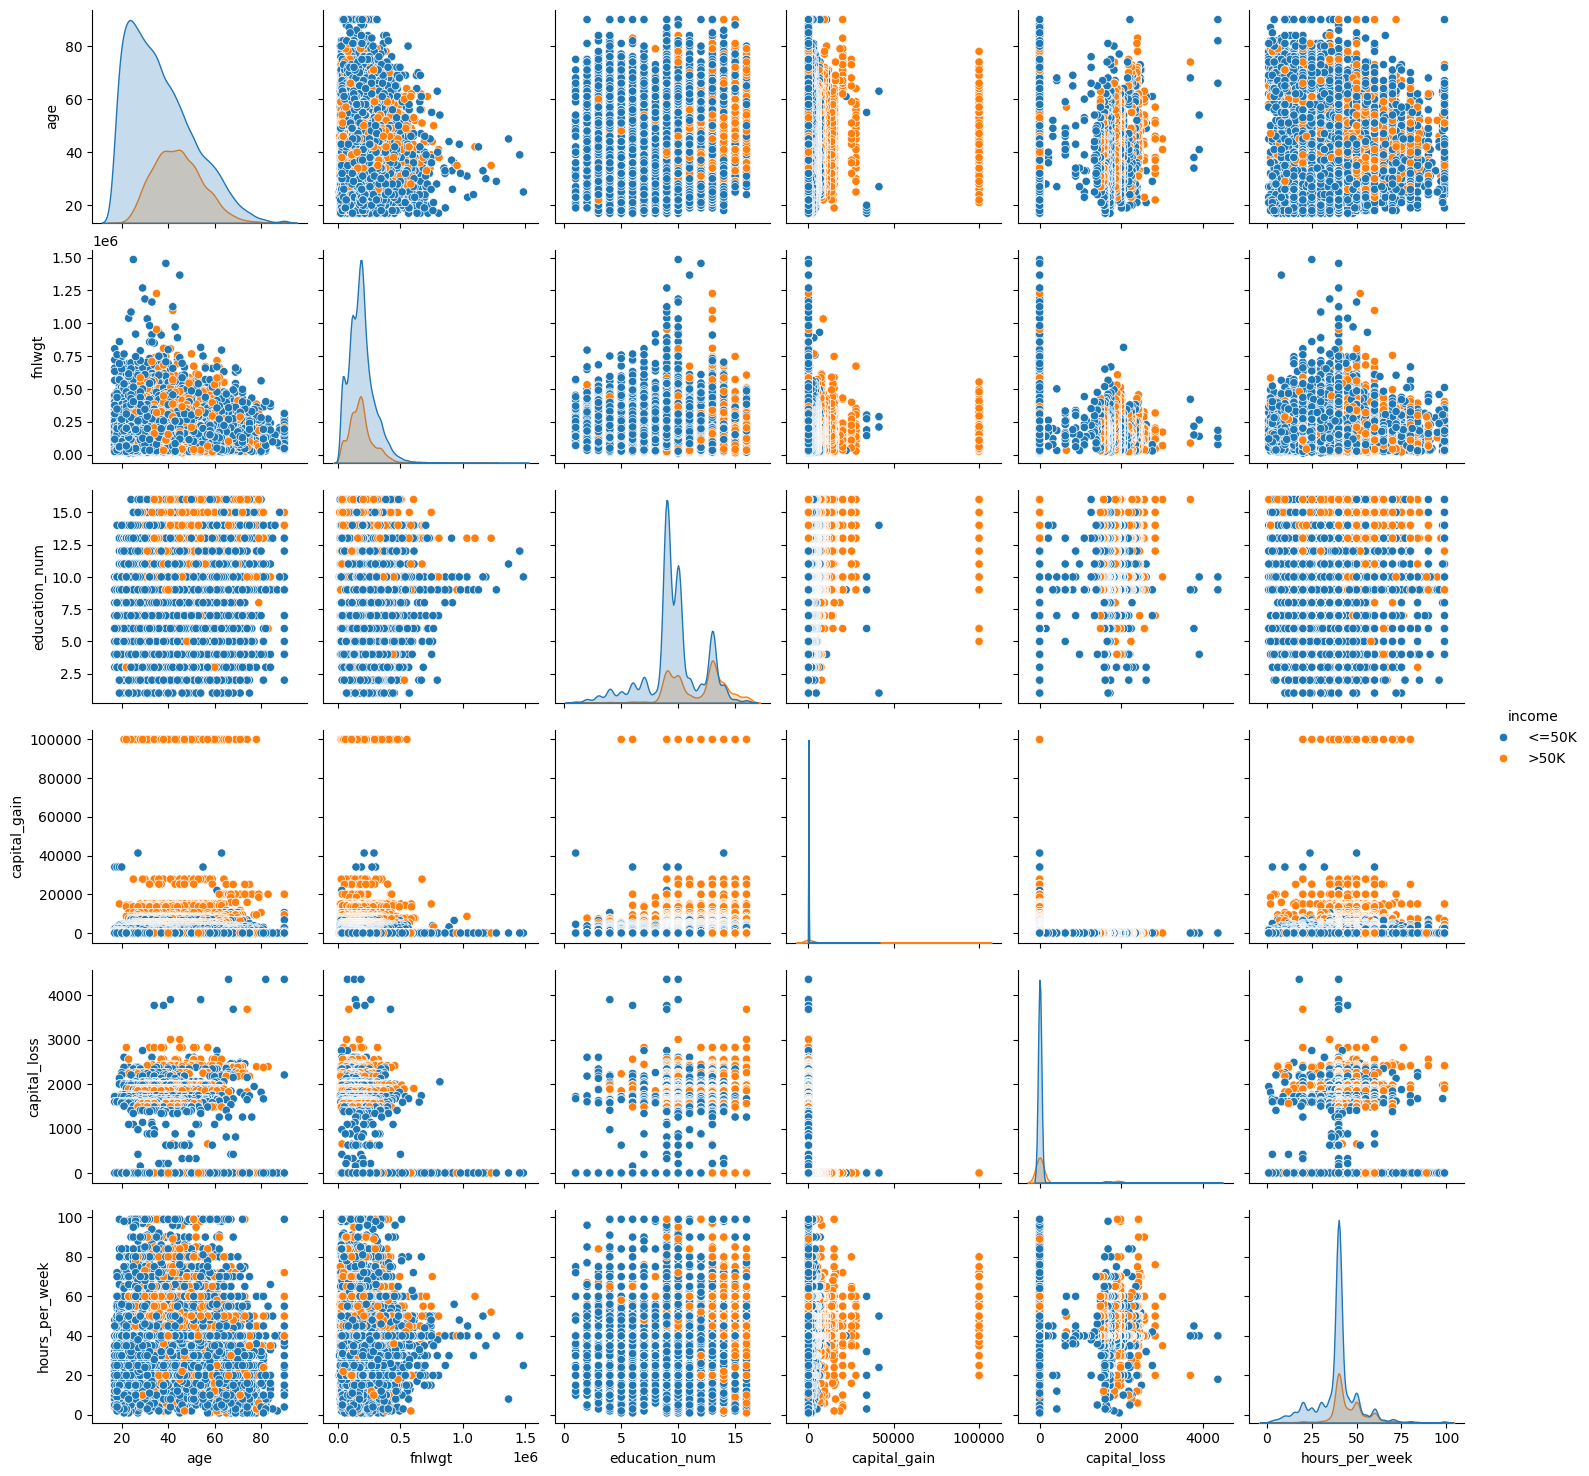

In [40]:
sns.pairplot(df,hue='income')

In [41]:
df.sample()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
16741,33,Self-emp-not-inc,103860,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,0,50,United-States,<=50K


In [42]:
df.groupby('income')['education_num'].mean()
# People who earn more than 50 K , are also have more education num. 

income
<=50K     9.596081
>50K     11.612195
Name: education_num, dtype: float64

In [43]:
df['education_num'].unique()

array([ 9, 10,  4,  6, 16, 15, 13, 14,  7, 12, 11,  2,  3,  8,  5,  1])

In [44]:
df.groupby('education_num')['income'].value_counts().sort_values()

education_num  income
2              >50K         6
3              >50K        16
5              >50K        27
8              >50K        33
4              >50K        40
1              <=50K       50
7              >50K        60
6              >50K        62
16             <=50K      107
15             <=50K      153
2              <=50K      160
12             >50K       265
16             >50K       306
3              <=50K      316
11             >50K       361
8              <=50K      400
15             >50K       423
5              <=50K      487
4              <=50K      605
14             <=50K      763
12             <=50K      802
6              <=50K      871
14             >50K       959
11             <=50K     1021
7              <=50K     1115
10             >50K      1386
9              >50K      1674
13             >50K      2221
               <=50K     3132
10             <=50K     5896
9              <=50K     8820
Name: count, dtype: int64

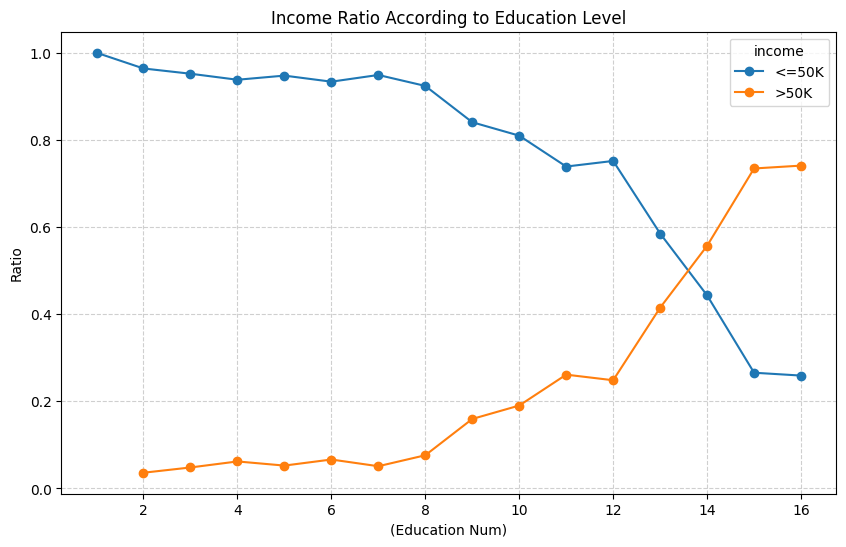

In [45]:
import seaborn as sns
import matplotlib.pyplot as plt

# Lets prepare the data(Looking to the ratio will make look the trend better.)
edu_income = df.groupby('education_num')['income'].value_counts(normalize=True).unstack()

# Line Graph
edu_income.plot(kind='line', marker='o', figsize=(10, 6))

plt.title('Income Ratio According to Education Level')
plt.xlabel('(Education Num)')
plt.ylabel('Ratio')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

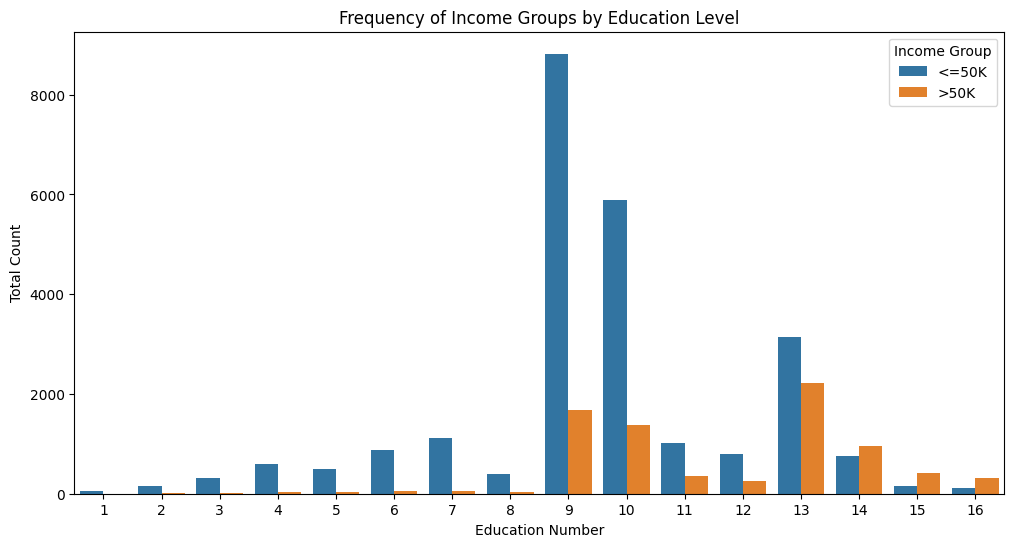

In [46]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='education_num', hue='income')

plt.title('Frequency of Income Groups by Education Level')
plt.xlabel('Education Number')
plt.ylabel('Total Count')
plt.legend(title='Income Group')
plt.show()

In [47]:
df.sample(5)

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
25378,29,Private,370509,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,50,France,>50K
16155,18,Private,27780,HS-grad,9,Never-married,Sales,Own-child,White,Female,0,0,25,United-States,<=50K
859,40,Private,119101,Some-college,10,Married-civ-spouse,Craft-repair,Husband,White,Male,0,1887,68,United-States,>50K
23535,42,Private,188808,Bachelors,13,Divorced,Adm-clerical,Unmarried,White,Male,0,0,30,United-States,<=50K
18064,43,Federal-gov,155106,Bachelors,13,Married-civ-spouse,Handlers-cleaners,Husband,White,Male,0,0,53,United-States,<=50K


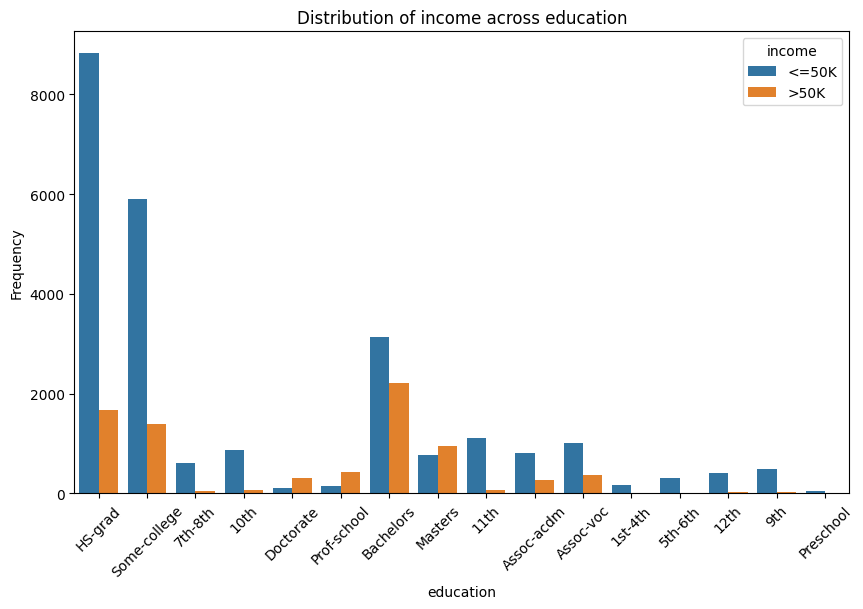

In [48]:


plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='education', hue='income')
plt.title('Distribution of income across education')
plt.xlabel('education')
plt.ylabel('Frequency')
plt.xticks(rotation = 45)
plt.show()

C:\Users\missena\AppData\Local\Temp\ipykernel_6284\711231780.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='income', y='capital_gain', palette='Set2')


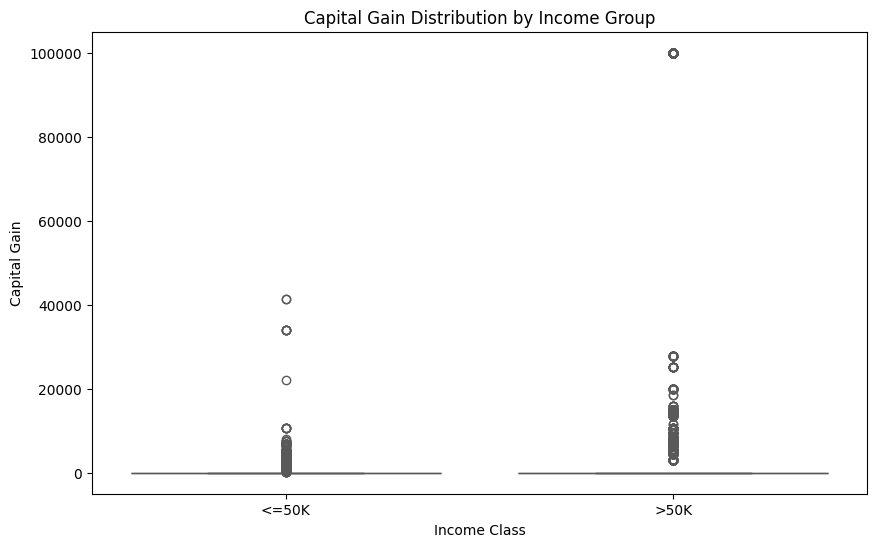

In [49]:
plt.figure(figsize=(10, 6))
# Using log scale might be better if values are very high
sns.boxplot(data=df, x='income', y='capital_gain', palette='Set2')

plt.title('Capital Gain Distribution by Income Group')
plt.xlabel('Income Class')
plt.ylabel('Capital Gain')
plt.show()

C:\Users\missena\AppData\Local\Temp\ipykernel_6284\2281536059.py:2: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['income'] == '>50K']['capital_gain'], label='>50K', shade=True)
C:\Users\missena\AppData\Local\Temp\ipykernel_6284\2281536059.py:3: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data=df[df['income'] <= '<=50K']['capital_gain'], label='<=50K', shade=True)


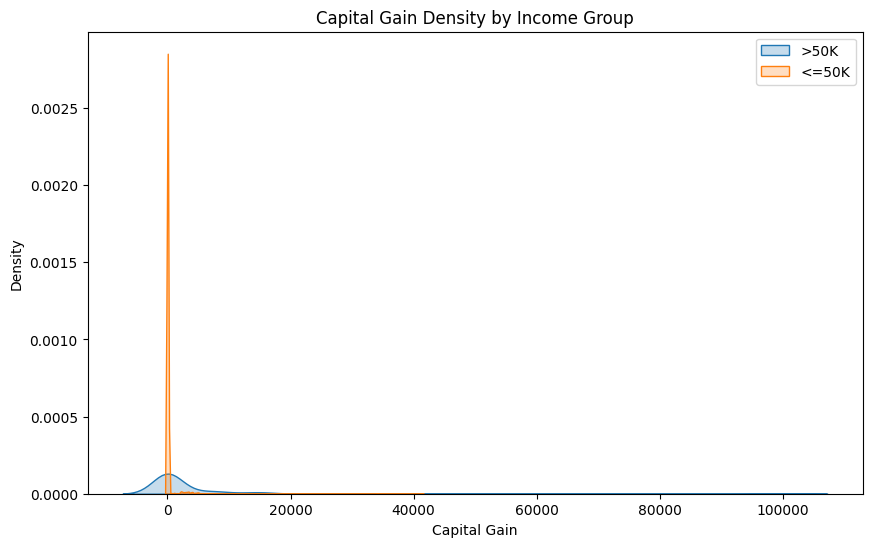

In [50]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['income'] == '>50K']['capital_gain'], label='>50K', shade=True)
sns.kdeplot(data=df[df['income'] <= '<=50K']['capital_gain'], label='<=50K', shade=True)

plt.title('Capital Gain Density by Income Group')
plt.xlabel('Capital Gain')
plt.ylabel('Density')
plt.legend()
plt.show()

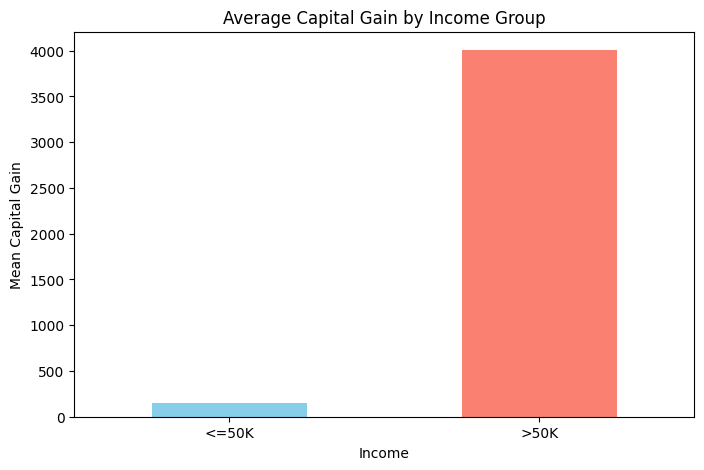

In [51]:
plt.figure(figsize=(8, 5))
df.groupby('income')['capital_gain'].mean().plot(kind='bar', color=['skyblue', 'salmon'])

plt.title('Average Capital Gain by Income Group')
plt.ylabel('Mean Capital Gain')
plt.xlabel('Income')
plt.xticks(rotation=0)
plt.show()

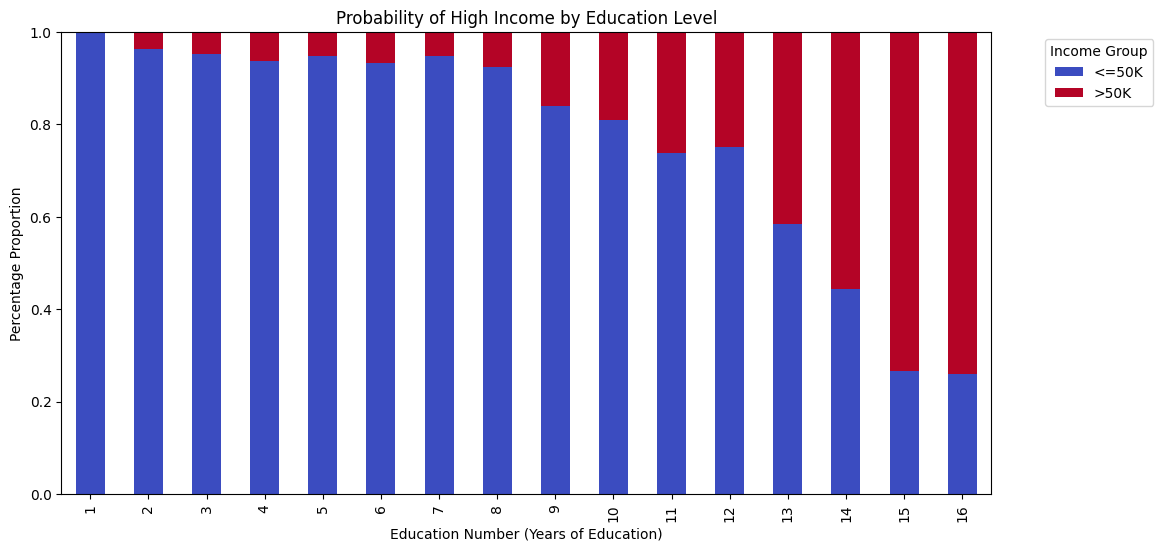

In [52]:
# Normalize the data to see the percentage share
edu_income_pct = pd.crosstab(df['education_num'], df['income'], normalize='index')

edu_income_pct.plot(kind='bar', stacked=True, figsize=(12, 6), colormap='coolwarm')

plt.title('Probability of High Income by Education Level')
plt.xlabel('Education Number (Years of Education)')
plt.ylabel('Percentage Proportion')
plt.legend(title='Income Group', bbox_to_anchor=(1.05, 1))
plt.show()

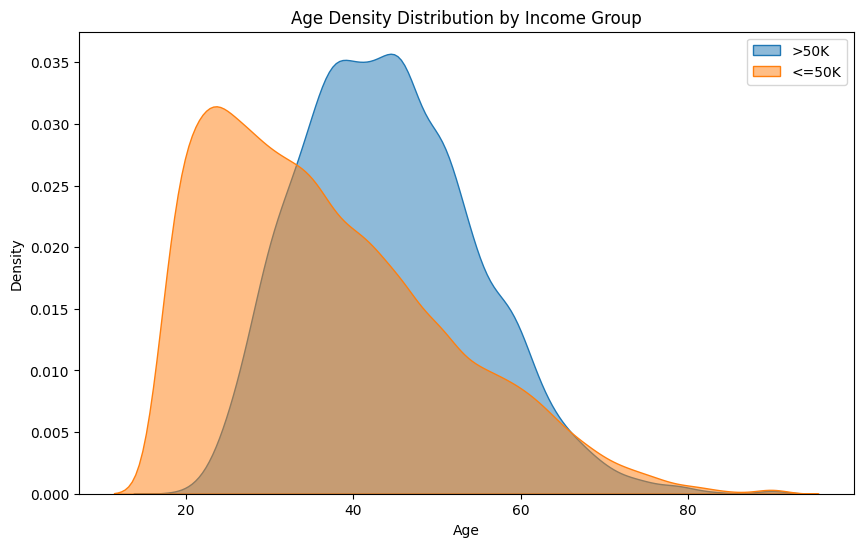

In [53]:
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df[df['income'] == '>50K']['age'], label='>50K', fill=True, alpha=0.5)
sns.kdeplot(data=df[df['income'] == '<=50K']['age'], label='<=50K', fill=True, alpha=0.5)

plt.title('Age Density Distribution by Income Group')
plt.xlabel('Age')
plt.ylabel('Density')
plt.legend()
plt.show()

C:\Users\missena\AppData\Local\Temp\ipykernel_6284\847937112.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=occ_income_sorted.values, y=occ_income_sorted.index, palette='magma')


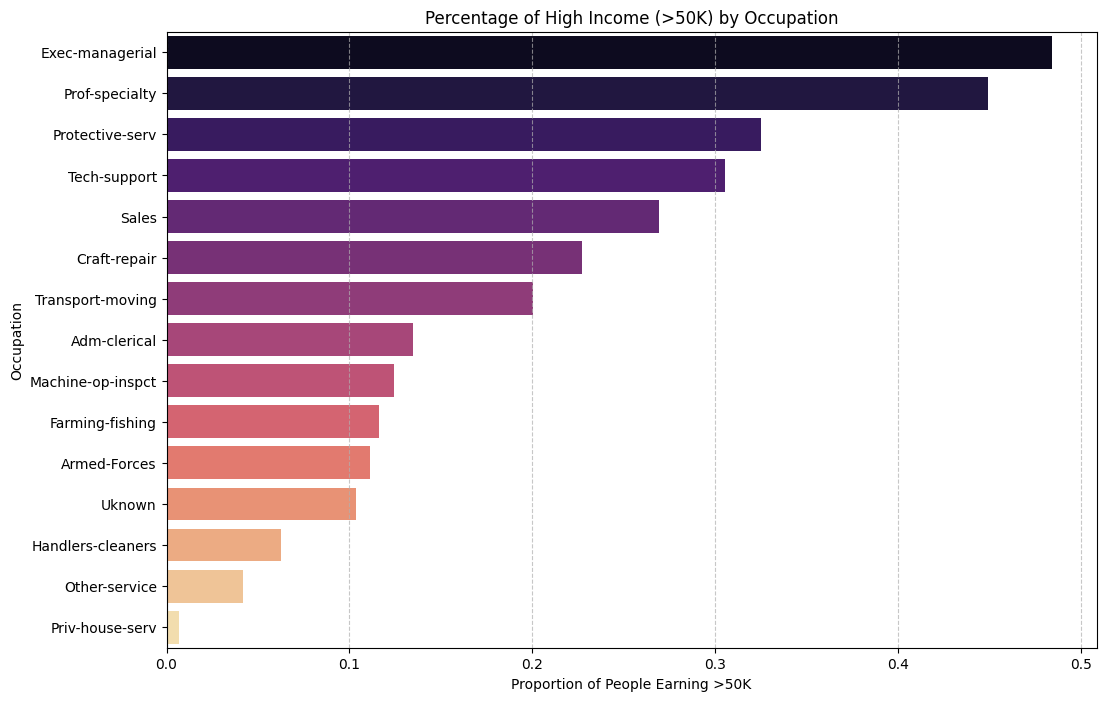

In [54]:

# Calculate the percentage of >50K for each occupation
occ_income = df.groupby('occupation')['income'].value_counts(normalize=True).unstack()
occ_income_sorted = occ_income['>50K'].sort_values(ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x=occ_income_sorted.values, y=occ_income_sorted.index, palette='magma')

plt.title('Percentage of High Income (>50K) by Occupation')
plt.xlabel('Proportion of People Earning >50K')
plt.ylabel('Occupation')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

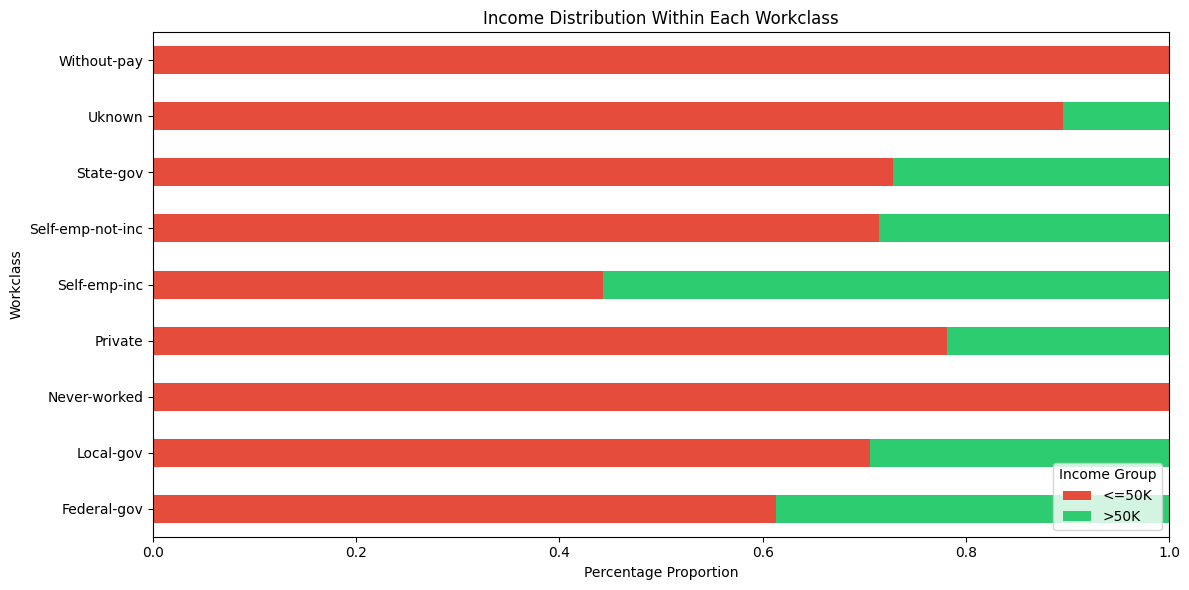

In [55]:
# Create a crosstab for Workclass and Income
work_income = pd.crosstab(df['workclass'], df['income'], normalize='index')

# Plotting
work_income.plot(kind='barh', stacked=True, figsize=(12, 6), color=['#e64c3c', '#2ecc71'])

plt.title('Income Distribution Within Each Workclass')
plt.xlabel('Percentage Proportion')
plt.ylabel('Workclass')
plt.legend(title='Income Group', loc='lower right')
plt.tight_layout()
plt.show()

In [56]:
def color_correlation2(val):

    if (0.9 <= val < 0.99999) or (-0.99999 < val <= -0.6):
        color = 'red'

    elif (0.3 <= val < 0.9) or (-0.6 < val <= -0.3):
        color = 'blue'

    elif val == 1:
        color = 'green'

    else:
        color = 'black'

    return f'color: {color}'


df.corr(numeric_only=True).style.map(color_correlation2)

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week
age,1.000000,-0.076447,0.036224,0.077676,0.057745,0.068515
fnlwgt,-0.076447,1.000000,-0.043388,0.000429,-0.010260,-0.018898
education_num,0.036224,-0.043388,1.000000,0.122664,0.079892,0.148422
capital_gain,0.077676,0.000429,0.122664,1.000000,-0.031639,0.078408
capital_loss,0.057745,-0.010260,0.079892,-0.031639,1.000000,0.054229
hours_per_week,0.068515,-0.018898,0.148422,0.078408,0.054229,1.000000


# MACHINE LEARNING MODELS

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

In [58]:
X = df.drop('income',axis=1)
y = df['income']

# EVAL

In [59]:
from sklearn.metrics import accuracy_score, recall_score, f1_score, precision_score, log_loss
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

In [60]:
def eval_metric(model, X_train, y_train, X_test, y_test):
    y_train_pred = model.predict(X_train)
    y_pred = model.predict(X_test)
    
    print("Test_Set")
    print(confusion_matrix(y_test, y_pred))
    print(classification_report(y_test, y_pred))
    print()
    print("Train_Set")
    print(confusion_matrix(y_train, y_train_pred))
    print(classification_report(y_train, y_train_pred))

# LOGISTIC REGRESSION

In [61]:
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X, y, test_size=0.2, random_state=42)


In [62]:
df.sample()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
28349,49,Private,97411,7th-8th,4,Never-married,Machine-op-inspct,Not-in-family,Asian-Pac-Islander,Male,0,0,45,Laos,<=50K


In [63]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ],
    remainder='passthrough'
)

X_train_lr = preprocessor.fit_transform(X_train_lr)
X_test_lr = preprocessor.transform(X_test_lr)

In [64]:
log_model = LogisticRegression(class_weight='balanced')
log_model.fit(X_train_lr, y_train_lr)
#it gives more importance to the minority class
# increases the recall effectively.

c:\Users\missena\anaconda3\envs\adult_ml\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [65]:
log_model.coef_

array([[ 5.64872715e-04, -1.78870019e-05, -9.06993356e-03,
         2.37142256e-03, -2.48210987e-04,  1.13210831e-04,
        -2.69071249e-03, -3.88417355e-05, -2.20393111e-03,
        -6.61013413e-04, -3.14214030e-04, -6.29001665e-04,
        -1.24297088e-03, -9.66164243e-04, -2.10414651e-04,
        -1.74205946e-04,  6.86610784e-03,  1.42872302e-03,
        -9.17631443e-03,  3.96394732e-03, -1.13060146e-04,
         1.69151506e-03, -4.47268946e-03,  5.90022900e-05,
         2.38800301e-02, -6.99294325e-04, -2.06531594e-02,
        -1.79055932e-03, -1.85126855e-03, -1.93200476e-05,
        -1.12349817e-03,  7.28937027e-03, -1.57098421e-03,
        -2.34130125e-03, -2.31871992e-03, -6.36773928e-03,
        -3.30777217e-04,  5.78659963e-03,  6.04607168e-04,
         1.13229656e-04,  3.23913581e-04, -9.49326227e-04,
        -2.70859949e-03, -1.26725236e-02, -1.99487372e-03,
        -1.10253160e-02, -6.34693033e-03,  3.09276054e-03,
        -2.67322745e-04, -3.65110884e-03, -4.18686348e-0

In [66]:
log_model.intercept_

array([-0.00786584])

In [67]:
feature_names = preprocessor.get_feature_names_out()

coeff_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_model.coef_[0]
})

coeff_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
24,cat__marital_status_Married-civ-spouse,0.023880
96,remainder__education_num,0.018172
94,remainder__age,0.014433
31,cat__occupation_Exec-managerial,0.007289
52,cat__sex_Male,0.007262
...,...,...
18,cat__education_HS-grad,-0.009176
99,remainder__hours_per_week,-0.010320
45,cat__relationship_Own-child,-0.011025
43,cat__relationship_Not-in-family,-0.012673


In [68]:
eval_metric(log_model, X_train_lr, y_train_lr, X_test_lr, y_test_lr)

Test_Set
[[3502 1486]
 [ 666  854]]
              precision    recall  f1-score   support

       <=50K       0.84      0.70      0.76      4988
        >50K       0.36      0.56      0.44      1520

    accuracy                           0.67      6508
   macro avg       0.60      0.63      0.60      6508
weighted avg       0.73      0.67      0.69      6508


Train_Set
[[13599  6111]
 [ 2683  3636]]
              precision    recall  f1-score   support

       <=50K       0.84      0.69      0.76     19710
        >50K       0.37      0.58      0.45      6319

    accuracy                           0.66     26029
   macro avg       0.60      0.63      0.60     26029
weighted avg       0.72      0.66      0.68     26029



In [69]:
# no overfitting
# model stabilize
# generalization is good

# LOGISTIC REGRESSION 2

In [70]:
X_train_lr2, X_test_lr2, y_train_lr2, y_test_lr2 = train_test_split(X, y, test_size=0.2, random_state=42)


In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression

categorical_features = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

numerical_features = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

pipeline_lr2 = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LogisticRegression(
        class_weight='balanced',
        max_iter=2000
    ))
])

pipeline_lr2.fit(X_train_lr2, y_train_lr2)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [72]:
eval_metric(pipeline_lr2, X_train_lr2, y_train_lr2, X_test_lr2, y_test_lr2)

Test_Set
[[3975 1013]
 [ 230 1290]]
              precision    recall  f1-score   support

       <=50K       0.95      0.80      0.86      4988
        >50K       0.56      0.85      0.67      1520

    accuracy                           0.81      6508
   macro avg       0.75      0.82      0.77      6508
weighted avg       0.86      0.81      0.82      6508


Train_Set
[[15760  3950]
 [  939  5380]]
              precision    recall  f1-score   support

       <=50K       0.94      0.80      0.87     19710
        >50K       0.58      0.85      0.69      6319

    accuracy                           0.81     26029
   macro avg       0.76      0.83      0.78     26029
weighted avg       0.85      0.81      0.82     26029



In [73]:
# no overfitting
# generalization is good
# better scores than the previous logistic regression model 

In [74]:
from sklearn.metrics import roc_auc_score

y_prob_lr2 = pipeline_lr2.predict_proba(X_test_lr2)[:,1]

roc_auc_score(y_test_lr2, y_prob_lr2)

0.9031697125733339

# DECISION TREES

#### Decision Tree

Unlike Logistic Regression:

It can learn nonlinear relationships
It doesn't require scaling
It can capture feature interactions

But:

It has a high risk of overfitting.

#### Pipeline for Decision Tree

The important point here is:

StandardScaler is not required for Decision Tree.

Because tree models:

are not distance-based
are not scale-sensitive.

In [75]:
X_train_dt, X_test_dt, y_train_dt, y_test_dt = train_test_split(X, y, test_size=0.2, random_state=42)


In [76]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier



categorical_features = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

numerical_features = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]

preprocessor_dt = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

pipeline_dt = Pipeline([
    ('preprocessor', preprocessor_dt),

    ('model', DecisionTreeClassifier(
        max_depth=10,
        min_samples_split=20,
        min_samples_leaf=10,
        random_state=42
    ))
])

pipeline_dt.fit(X_train_dt, y_train_dt)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains 

In [77]:
eval_metric(pipeline_dt, X_train_dt, y_train_dt, X_test_dt, y_test_dt)

Test_Set
[[4704  284]
 [ 617  903]]
              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      4988
        >50K       0.76      0.59      0.67      1520

    accuracy                           0.86      6508
   macro avg       0.82      0.77      0.79      6508
weighted avg       0.86      0.86      0.86      6508


Train_Set
[[18751   959]
 [ 2531  3788]]
              precision    recall  f1-score   support

       <=50K       0.88      0.95      0.91     19710
        >50K       0.80      0.60      0.68      6319

    accuracy                           0.87     26029
   macro avg       0.84      0.78      0.80     26029
weighted avg       0.86      0.87      0.86     26029



# K-NEAREST NEIGHBORS (KNN)

In [78]:
X_train_knn, X_test_knn, y_train_knn, y_test_knn = train_test_split(X, y, test_size=0.2, random_state=42)


In [79]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier

categorical_features = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

numerical_features = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

pipeline_knn = Pipeline([
    ('preprocessor', preprocessor),

    ('model', KNeighborsClassifier(
        n_neighbors=5
    ))
])

pipeline_knn.fit(X_train_knn, y_train_knn)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [80]:
y_pred_knn = pipeline_knn.predict(X_test_knn)

In [81]:
eval_metric(pipeline_knn, X_train_knn, y_train_knn, X_test_knn, y_test_knn)

Test_Set
[[4470  518]
 [ 583  937]]
              precision    recall  f1-score   support

       <=50K       0.88      0.90      0.89      4988
        >50K       0.64      0.62      0.63      1520

    accuracy                           0.83      6508
   macro avg       0.76      0.76      0.76      6508
weighted avg       0.83      0.83      0.83      6508


Train_Set
[[18456  1254]
 [ 1843  4476]]
              precision    recall  f1-score   support

       <=50K       0.91      0.94      0.92     19710
        >50K       0.78      0.71      0.74      6319

    accuracy                           0.88     26029
   macro avg       0.85      0.82      0.83     26029
weighted avg       0.88      0.88      0.88     26029



In [82]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score
# )

# import pandas as pd

# # Sonuçları saklamak için liste
# results = []

# # Model comparison function
# def compare_models(model_name, model, X_test, y_test):

#     y_pred = model.predict(X_test)

#     accuracy = accuracy_score(y_test, y_pred)

#     precision = precision_score(
#         y_test,
#         y_pred,
#         pos_label='>50K'
#     )

#     recall = recall_score(
#         y_test,
#         y_pred,
#         pos_label='>50K'
#     )

#     f1 = f1_score(
#         y_test,
#         y_pred,
#         pos_label='>50K'
#     )

#     results.append({
#         "Model": model_name,
#         "Accuracy": round(accuracy, 3),
#         "Precision": round(precision, 3),
#         "Recall": round(recall, 3),
#         "F1-Score": round(f1, 3)
#     })


# # Logistic Regression
# compare_models(
#     "Logistic Regression",
#     pipeline_lr2,
#     X_test_lr,
#     y_test_lr
# )

# # Decision Tree
# compare_models(
#     "Decision Tree",
#     pipeline_dt,
#     X_test_dt,
#     y_test_dt
# )

# # KNN
# compare_models(
#     "KNN",
#     pipeline_knn,
#     X_test_knn,
#     y_test_knn
# )

# # DataFrame oluştur
# results_df = pd.DataFrame(results)

# # F1-Score'a göre sırala
# results_df = results_df.sort_values(
#     by="F1-Score",
#     ascending=False
# )

# # Sonuçları göster
# display(
#     results_df.style.background_gradient(cmap='Blues')
# )

# RANDOM FOREST

In [83]:
# Random Forest

# This model:

# creates many Decision Trees
# combines results (voting)
# reduces overfitting
# generally works very well on tabular data

# It is one of the best classic models for adult datasets.

In [84]:
# Advantages of Random Forest

# Learns nonlinear relationships
# Captures feature interaction
# Reduces overfitting
# Assigns feature importance
# No scaling required

In [ ]:
X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(X, y, test_size=0.2, random_state=42)


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier

# categorical ve numerical feature'lar
categorical_features = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

numerical_features = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per-_week'
]

# preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(handle_unknown='ignore'),
            categorical_features
        )
    ],
    remainder='passthrough'
)

# Random Forest Pipeline
pipeline_rf = Pipeline([

    ('preprocessor', preprocessor),

    ('model', RandomForestClassifier(
        n_estimators=300,
        max_depth=20,
        min_samples_split=10,
        min_samples_leaf=2,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ))
])

# modeli eğit
pipeline_rf.fit(X_train_rf, y_train_rf)

# prediction
y_pred_rf = pipeline_rf.predict(X_test_rf)


In [96]:
# y_pred_rf = pipeline_rf.predict(X_test_rf)

In [100]:
eval_metric(pipeline_rf, X_train_rf, y_train_rf, X_test_rf, y_test_rf)

Test_Set
[[4014  974]
 [ 207 1313]]
              precision    recall  f1-score   support

       <=50K       0.95      0.80      0.87      4988
        >50K       0.57      0.86      0.69      1520

    accuracy                           0.82      6508
   macro avg       0.76      0.83      0.78      6508
weighted avg       0.86      0.82      0.83      6508


Train_Set
[[16282  3428]
 [  569  5750]]
              precision    recall  f1-score   support

       <=50K       0.97      0.83      0.89     19710
        >50K       0.63      0.91      0.74      6319

    accuracy                           0.85     26029
   macro avg       0.80      0.87      0.82     26029
weighted avg       0.88      0.85      0.85     26029



# XGBOOST

In [104]:
pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)
Note: you may need to restart the kernel to use updated packages.


In [106]:
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(X, y, test_size=0.2, random_state=42)


In [107]:


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.metrics import classification_report

from xgboost import XGBClassifier

# -----------------------------
# FEATURE LISTS
# -----------------------------
categorical_features = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

numerical_features = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]

# -----------------------------
# LABEL ENCODING (TARGET)
# -----------------------------
le = LabelEncoder()

y_train_xgb = le.fit_transform(y_train_xgb)
y_test_xgb = le.transform(y_test_xgb)

# -----------------------------
# PREPROCESSING
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

# -----------------------------
# MODEL
# -----------------------------
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=42,
    n_jobs=-1
)

# -----------------------------
# PIPELINE
# -----------------------------
pipeline_xgb = Pipeline([
    ('preprocessor', preprocessor),
    ('model', xgb_model)
])

# -----------------------------
# TRAIN
# -----------------------------
pipeline_xgb.fit(X_train_xgb, y_train_xgb)

# -----------------------------
# PREDICTION
# -----------------------------
y_pred_xgb = pipeline_xgb.predict(X_test_xgb)

# -----------------------------
# EVALUATION
# -----------------------------
print(classification_report(y_test_xgb, y_pred_xgb))

# -----------------------------
# (OPTIONAL) BACK TO ORIGINAL LABELS
# -----------------------------
print(le.inverse_transform([0, 1]))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4988
           1       0.76      0.67      0.71      1520

    accuracy                           0.87      6508
   macro avg       0.83      0.80      0.82      6508
weighted avg       0.87      0.87      0.87      6508

['<=50K' '>50K']


# SUPPORT VECTOR MACHINE (SVM)

In [114]:
X_train_svm, X_test_svm, y_train_svm, y_test_svm = train_test_split(X, y, test_size=0.2, random_state=42)


In [115]:


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report

# -----------------------------
# FEATURE LISTS
# -----------------------------
categorical_features = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country'
]

numerical_features = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]

# -----------------------------
# PREPROCESSING
# -----------------------------
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', StandardScaler(), numerical_features)
    ]
)

# -----------------------------
# MODEL
# -----------------------------
svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale'
)

# -----------------------------
# PIPELINE
# -----------------------------
pipeline_svm = Pipeline([
    ('preprocessor', preprocessor),
    ('model', svm_model)
])

# -----------------------------
# TRAIN
# -----------------------------
pipeline_svm.fit(X_train_svm, y_train_svm)

# -----------------------------
# PREDICTION
# -----------------------------
y_pred_svm = pipeline_svm.predict(X_test_svm)

# -----------------------------
# EVALUATION
# -----------------------------
print(classification_report(y_test_svm, y_pred_svm))

              precision    recall  f1-score   support

       <=50K       0.88      0.94      0.91      4988
        >50K       0.74      0.60      0.66      1520

    accuracy                           0.86      6508
   macro avg       0.81      0.77      0.79      6508
weighted avg       0.85      0.86      0.85      6508



# NAIVE BAYES

# MODEL COMPARISON

In [ ]:
# from sklearn.metrics import (
#     accuracy_score,
#     precision_score,
#     recall_score,
#     f1_score
# )

# import pandas as pd

# # Sonuçları saklamak için liste
# results = []

# # Model comparison function
# def compare_models(model_name, model, X_test, y_test):

#     y_pred = model.predict(X_test)

#     accuracy = accuracy_score(y_test, y_pred)

#     precision = precision_score(
#         y_test,
#         y_pred,
#         pos_label='>50K'
#     )

#     recall = recall_score(
#         y_test,
#         y_pred,
#         pos_label='>50K'
#     )

#     f1 = f1_score(
#         y_test,
#         y_pred,
#         pos_label='>50K'
#     )

#     results.append({
#         "Model": model_name,
#         "Accuracy": round(accuracy, 3),
#         "Precision": round(precision, 3),
#         "Recall": round(recall, 3),
#         "F1-Score": round(f1, 3)
#     })


# # Logistic Regression
# compare_models(
#     "Logistic Regression",
#     pipeline_lr2,
#     X_test_lr2,
#     y_test_lr2
# )

# # Decision Tree
# compare_models(
#     "Decision Tree",
#     pipeline_dt,
#     X_test_dt,
#     y_test_dt
# )

# # KNN
# compare_models(
#     "KNN",
#     pipeline_knn,
#     X_test_knn,
#     y_test_knn
# )

# # Random Forest  
# compare_models(
#     "Random Forest",
#     pipeline_rf,
#     X_test_rf,
#     y_test_rf
# )

# compare_models(
#     "XGBoost",
#     pipeline_xgb,
#     X_test_xgb,
#     y_test_xgb
# )

# # DataFrame oluştur
# results_df = pd.DataFrame(results)

# # F1-Score'a göre sırala
# results_df = results_df.sort_values(
#     by="F1-Score",
#     ascending=False
# )

# # Sonuçları göster
# display(
#     results_df.style.background_gradient(cmap='Blues')
# )

ValueError: pos_label=>50K is not a valid label. It should be one of [0, 1]

In [117]:

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

import pandas as pd

# -----------------------------
# RESULT STORAGE
# -----------------------------
results = []

# -----------------------------
# UPDATED COMPARISON FUNCTION
# -----------------------------
def compare_models(model_name, model, X_test, y_test, pos_label=None):

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    # binary classification handling
    if pos_label is not None:
        precision = precision_score(y_test, y_pred, pos_label=pos_label)
        recall = recall_score(y_test, y_pred, pos_label=pos_label)
        f1 = f1_score(y_test, y_pred, pos_label=pos_label)
    else:
        precision = precision_score(y_test, y_pred)
        recall = recall_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": round(accuracy, 3),
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "F1-Score": round(f1, 3)
    })


# -----------------------------
# LOGISTIC REGRESSION
# -----------------------------
compare_models(
    "Logistic Regression",
    pipeline_lr2,
    X_test_lr2,
    y_test_lr2,
    pos_label='>50K'
)

# -----------------------------
# DECISION TREE
# -----------------------------
compare_models(
    "Decision Tree",
    pipeline_dt,
    X_test_dt,
    y_test_dt,
    pos_label='>50K'
)

# -----------------------------
# KNN
# -----------------------------
compare_models(
    "KNN",
    pipeline_knn,
    X_test_knn,
    y_test_knn,
    pos_label='>50K'
)

# -----------------------------
# RANDOM FOREST
# -----------------------------
compare_models(
    "Random Forest",
    pipeline_rf,
    X_test_rf,
    y_test_rf,
    pos_label='>50K'
)

# -----------------------------
# XGBOOST (IMPORTANT: encoded labels 0/1)
# -----------------------------
compare_models(
    "XGBoost",
    pipeline_xgb,
    X_test_xgb,
    y_test_xgb,
    pos_label=None
)

compare_models(
    "SVM",
    pipeline_svm,
    X_test_svm,
    y_test_svm,
    pos_label='>50K'
)

# -----------------------------
# DATAFRAME
# -----------------------------
results_df = pd.DataFrame(results)

# Sort by F1-score
results_df = results_df.sort_values(by="F1-Score", ascending=False)

# Display styled table
display(
    results_df.style.background_gradient(cmap='Blues')
)

,Model,Accuracy,Precision,Recall,F1-Score
4,XGBoost,0.874000,0.761000,0.671000,0.713000
3,Random Forest,0.819000,0.574000,0.864000,0.690000
0,Logistic Regression,0.809000,0.560000,0.849000,0.675000
1,Decision Tree,0.862000,0.761000,0.594000,0.667000
5,SVM,0.858000,0.743000,0.598000,0.663000
2,KNN,0.831000,0.644000,0.616000,0.630000


# 📊 Model Comparison Results Analysis

After training and evaluating multiple machine learning models on the dataset, the following results were obtained:

| Model                | Accuracy | Precision | Recall | F1-Score |
|---------------------|----------|-----------|--------|----------|
| XGBoost             | 0.874    | 0.761     | 0.671  | 0.713    |
| Random Forest       | 0.819    | 0.574     | 0.864  | 0.690    |
| Logistic Regression | 0.809    | 0.560     | 0.849  | 0.675    |
| Decision Tree       | 0.862    | 0.761     | 0.594  | 0.667    |
| KNN                 | 0.831    | 0.644     | 0.616  | 0.630    |

---

# 🏆 Key Findings

## 🥇 XGBoost (Best Overall Model)
- Achieved the highest **Accuracy (0.874)** and **F1-Score (0.713)**.
- Provides the best balance between **precision and recall**.
- Demonstrates strong generalization capability.
- Selected as the **final model** for deployment.

---

## 🥈 Random Forest
- Achieved the highest **recall (0.864)** among all models.
- However, relatively low precision (0.574) indicates more false positives.
- Strong model for recall-focused tasks, but less balanced than XGBoost.

---

## 🥉 Logistic Regression
- A solid baseline model with stable performance.
- Performs well in recall but lacks precision compared to advanced models.

---

## 🌳 Decision Tree
- High precision (0.761) but significantly lower recall (0.594).
- Indicates overfitting and limited generalization ability.

---

## 📌 SVM Model Analysis

The Support Vector Machine (SVM) model achieved competitive performance among all evaluated models.

- **Accuracy:** 0.858  
- **Precision:** 0.743  
- **Recall:** 0.598  
- **F1-Score:** 0.663 

---

## 📍 KNN
- Moderate performance across all metrics.
- Sensitive to feature scaling and less competitive compared to ensemble methods.

---

# 📌 Conclusion

- **XGBoost is the best performing model overall** based on accuracy and F1-score.
- Ensemble methods (XGBoost, Random Forest) significantly outperform traditional models.
- The final system should be built using **XGBoost as the production model**.

# FINAL MODEL

In [120]:

# -----------------------------
# FINAL MODEL SELECTION
# -----------------------------
final_model = pipeline_xgb

# -----------------------------
# TRAIN FINAL MODEL (if not already trained)
# -----------------------------
final_model.fit(X_train_xgb, y_train_xgb)

# -----------------------------
# PREDICTION
# -----------------------------
y_pred_final = final_model.predict(X_test_xgb)

# -----------------------------
# EVALUATION
# -----------------------------
from sklearn.metrics import classification_report, accuracy_score, f1_score

print("📌 FINAL MODEL: XGBoost")
print("Accuracy:", accuracy_score(y_test_xgb, y_pred_final))
print("F1 Score:", f1_score(y_test_xgb, y_pred_final))

print("\nClassification Report:\n")
print(classification_report(y_test_xgb, y_pred_final))

📌 FINAL MODEL: XGBoost
Accuracy: 0.8740012292563
F1 Score: 0.7132867132867133

Classification Report:

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      4988
           1       0.76      0.67      0.71      1520

    accuracy                           0.87      6508
   macro avg       0.83      0.80      0.82      6508
weighted avg       0.87      0.87      0.87      6508



# SAVING MODEL

In [122]:

import joblib

# Save final model
joblib.dump(final_model, "xgboost_final_model.pkl")

print("Model saved successfully!")

Model saved successfully!



## 🏆 Final Model Selection: XGBoost

Based on the evaluation of multiple machine learning models, **XGBoost has been selected as the final model**.

### 📊 Reasons for Selection:

- Highest Accuracy (0.874)
- Highest F1-Score (0.713)
- Strong balance between precision and recall
- Better generalization compared to other models
- Robust performance on mixed categorical + numerical dataset

### 🚀 Conclusion:

XGBoost provides the best trade-off between performance metrics and is therefore chosen as the **final production model** for deployment.

In [124]:

# saved modeli yükle
loaded_model = joblib.load("xgboost_final_model.pkl")

print("Model loaded successfully!")

Model loaded successfully!


In [125]:


sample = pd.DataFrame([{
    'age': 35,
    'fnlwgt': 200000,
    'education_num': 13,
    'capital_gain': 0,
    'capital_loss': 0,
    'hours_per_week': 40,
    'workclass': 'Private',
    'education': 'Bachelors',
    'marital_status': 'Married-civ-spouse',
    'occupation': 'Tech-support',
    'relationship': 'Husband',
    'race': 'White',
    'sex': 'Male',
    'native_country': 'United-States'
}])

In [126]:

prediction = loaded_model.predict(sample)

print("Prediction:", prediction)

Prediction: [1]


In [127]:
# 0 -> <=50K
# 1 -> >50K

In [128]:

if prediction[0] == 1:
    print("Income: >50K")
else:
    print("Income: <=50K")

Income: >50K
